In [1]:
import jax.numpy as jnp
import pyproj
import matplotlib.pyplot as plt
import matplotlib.patches as patches
plt.rcParams["font.size"] = 20
from OkadaJAX import OkadaWrapper
okada = OkadaWrapper()

var_list = [
    "ux", "uy", "uz", "uxx", "uyx", "uzx", "uxy", "uyy", "uzy", "uxz", "uyz", "uzz"
]

# Point source

In [2]:
# domain
lon_min, lon_max = 142, 148
lat_min, lat_max = 37, 43
dlon, dlat = 0.05, 0.05
nlon, nlat = int((lon_max-lon_min)/dlon)+1, int((lat_max-lat_min)/dlon)+1
lon_mid, lat_mid = (lon_min+lon_max)/2, (lat_min+lat_max)/2

# coordinate transformation
ll2xy = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326", # WGS84
    crs_to=f"+proj=tmerc +lon_0={lon_mid} +lat_0={lat_mid} +ellps=WGS84 +datum=WGS84 +units=km", 
    always_xy=True
)

lon = jnp.linspace(lon_min, lon_max, nlon)
lat = jnp.linspace(lat_min, lat_max, nlat)
Lon, Lat = jnp.meshgrid(lon, lat)
X, Y = ll2xy.transform(Lon, Lat)


# source parameters
lat_fault = 40.2224
lon_fault = 144.8678
x_fault, y_fault = ll2xy.transform(lon_fault, lat_fault) # km

x_fault = jnp.array(x_fault)
y_fault = jnp.array(y_fault)
depth = 0.1 # km
strike = jnp.array(189.0)
dip = jnp.array(60.0)
rake = jnp.array(270.0)
slip = jnp.array(5.62*1e4) # just amplify

## `z` is not given (`SPOINT` is called)

In [3]:
coords = {
    "x": X,
    "y": Y
}
params = {
    "x_fault": x_fault,
    "y_fault": y_fault,
    "depth": depth,
    "strike": strike,
    "dip": dip,
    "rake": rake,
    "slip": slip
}

out = okada.compute(coords, params, compute_strain=True, is_degree=True, fault_origin="topleft")
out

[Array([[-0.01273695, -0.01256325, -0.01238314, ...,  0.02328659,
          0.02336451,  0.02343372],
        [-0.01328556, -0.01310968, -0.01292696, ...,  0.02409121,
          0.02416413,  0.02422794],
        [-0.01386221, -0.0136844 , -0.0134993 , ...,  0.02492968,
          0.02499688,  0.02505456],
        ...,
        [-0.03207475, -0.03202143, -0.03195377, ...,  0.01894279,
          0.01907063,  0.01918852],
        [-0.03083502, -0.03077031, -0.03069195, ...,  0.01808589,
          0.01821767,  0.01834002],
        [-0.02965064, -0.02957603, -0.02948836, ...,  0.0172717 ,
          0.01740659,  0.01753252]], dtype=float32),
 Array([[-0.00361146, -0.00353708, -0.00345889, ..., -0.01443886,
         -0.01439913, -0.01435279],
        [-0.00378749, -0.00371313, -0.00363468, ..., -0.01485581,
         -0.01480778, -0.01475303],
        [-0.00397179, -0.00389767, -0.0038192 , ..., -0.0152848 ,
         -0.01522784, -0.01516404],
        ...,
        [ 0.01975161,  0.01984181,  0.0

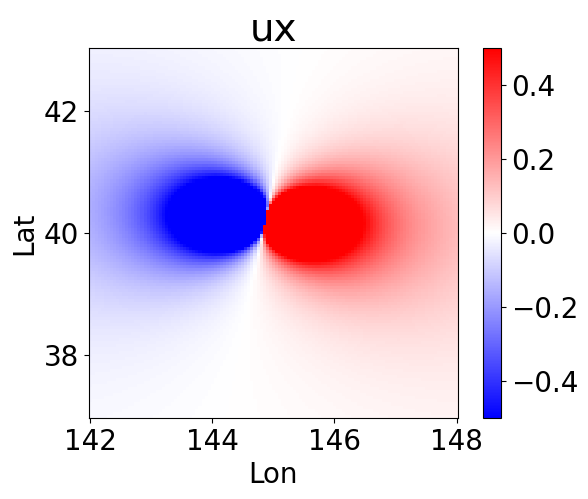

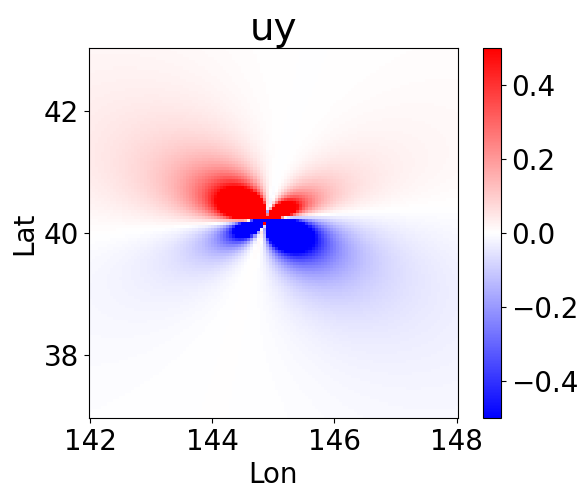

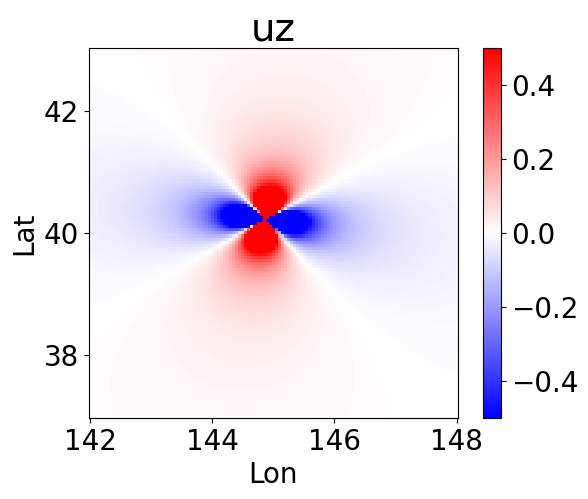

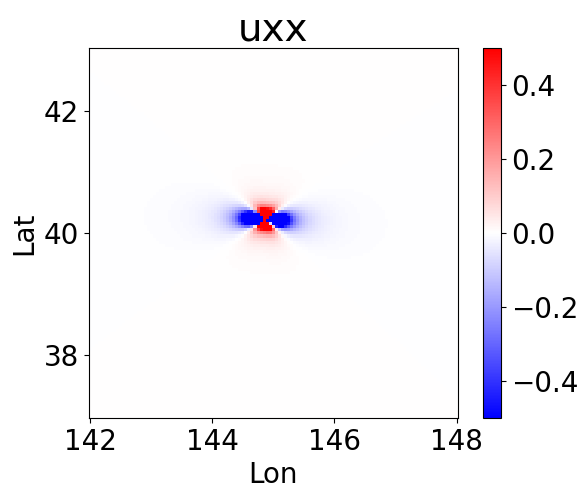

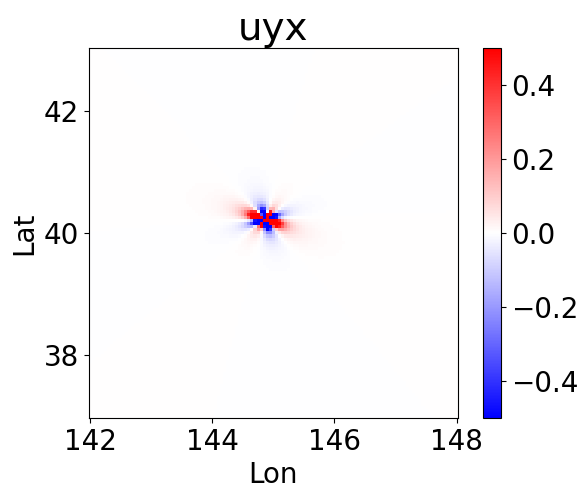

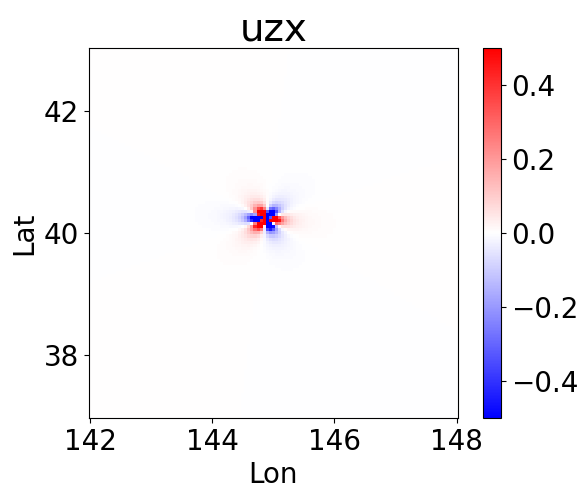

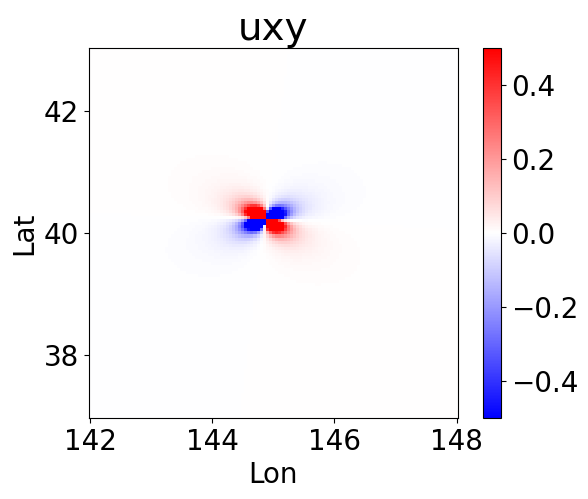

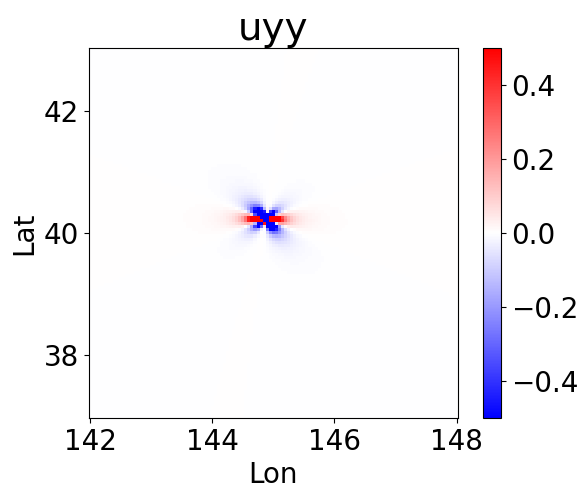

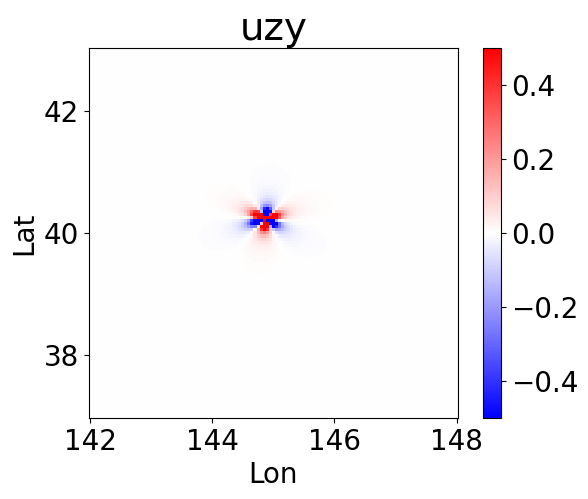

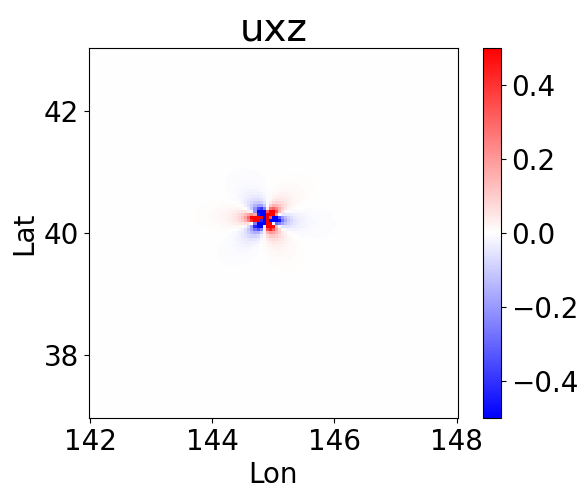

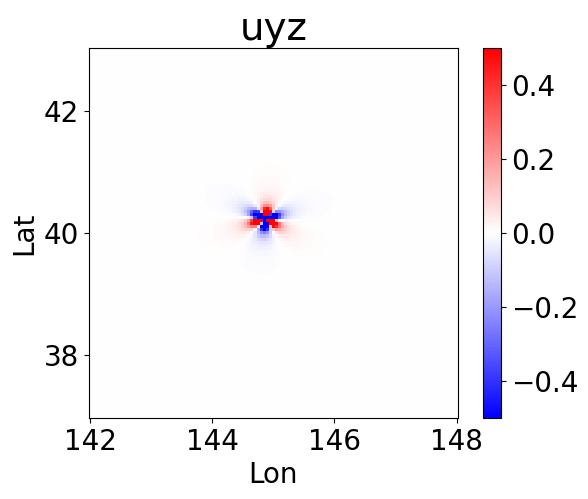

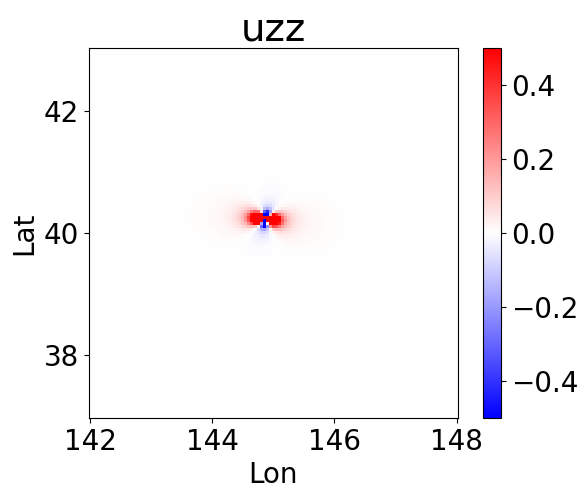

In [4]:
for i, var in enumerate(var_list):

    fig, ax = plt.subplots()
    im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.5, vmax=0.5)
    ax.set_aspect("equal")
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(var, fontsize=28)
    fig.colorbar(im)
    fig.show()

## `z` is given (`DC3D0` is called)

In [5]:
Z = jnp.zeros_like(X)

coords = {
    "x": X,
    "y": Y,
    "z": Z
}
params = {
    "x_fault": x_fault,
    "y_fault": y_fault,
    "depth": depth,
    "strike": strike,
    "dip": dip,
    "rake": rake,
    "slip": slip
}

out = okada.compute(coords, params, compute_strain=True, is_degree=True, fault_origin="topleft")
out

[Array([[-0.01273695, -0.01256326, -0.01238314, ...,  0.02328659,
          0.02336451,  0.02343372],
        [-0.01328556, -0.01310968, -0.01292696, ...,  0.02409121,
          0.02416413,  0.02422794],
        [-0.01386221, -0.0136844 , -0.0134993 , ...,  0.02492968,
          0.02499687,  0.02505456],
        ...,
        [-0.03207475, -0.03202143, -0.03195377, ...,  0.01894279,
          0.01907063,  0.01918852],
        [-0.03083502, -0.03077031, -0.03069195, ...,  0.01808589,
          0.01821767,  0.01834002],
        [-0.02965064, -0.02957603, -0.02948836, ...,  0.0172717 ,
          0.01740659,  0.01753252]], dtype=float32),
 Array([[-0.00361146, -0.00353708, -0.00345889, ..., -0.01443886,
         -0.01439912, -0.01435279],
        [-0.00378749, -0.00371313, -0.00363468, ..., -0.01485581,
         -0.01480778, -0.01475303],
        [-0.00397179, -0.00389767, -0.0038192 , ..., -0.0152848 ,
         -0.01522784, -0.01516404],
        ...,
        [ 0.01975161,  0.01984181,  0.0

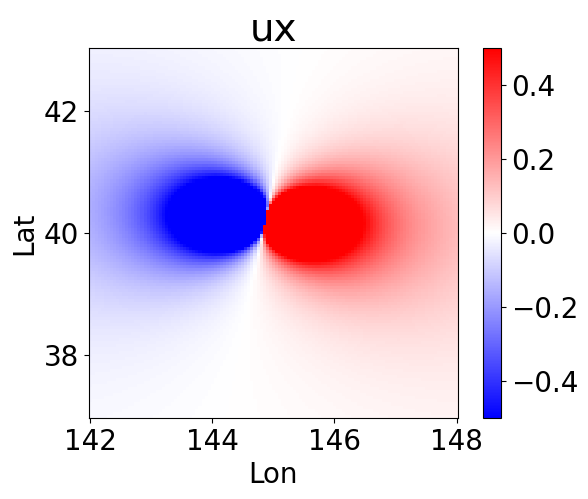

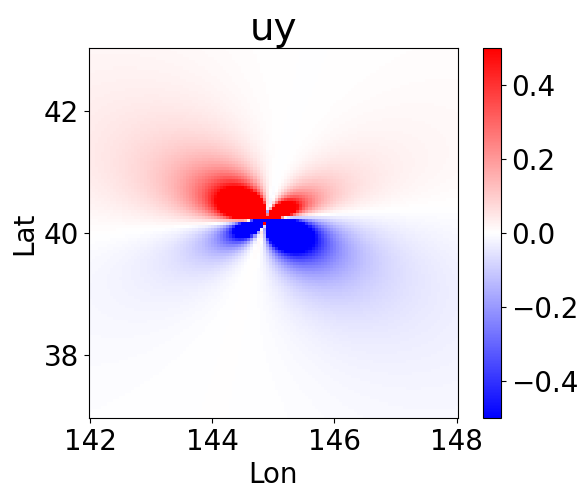

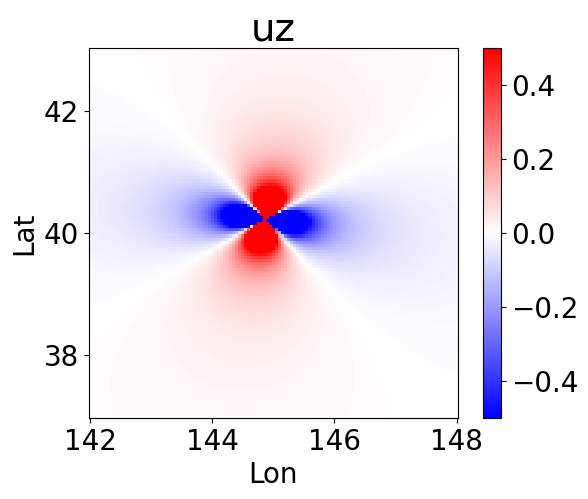

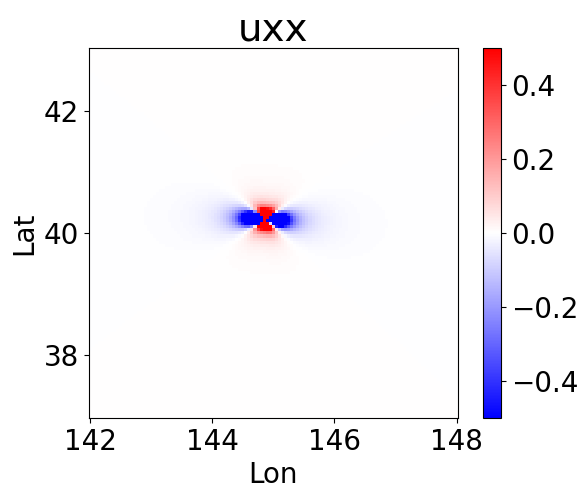

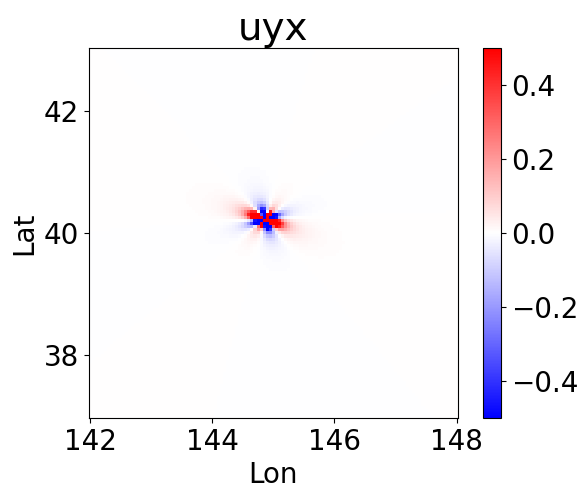

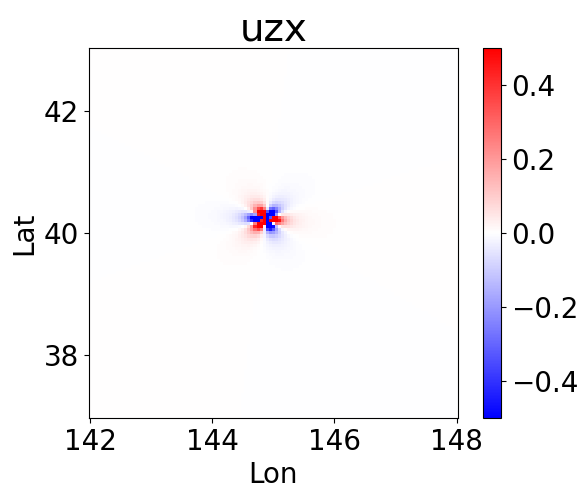

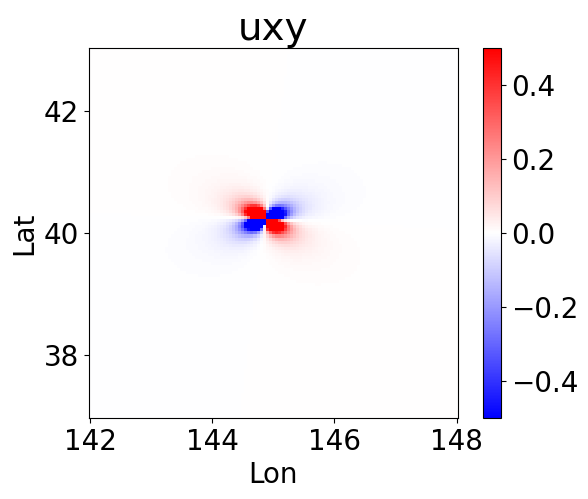

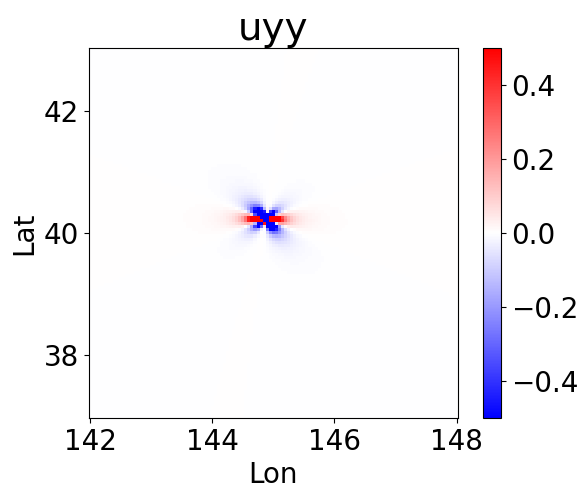

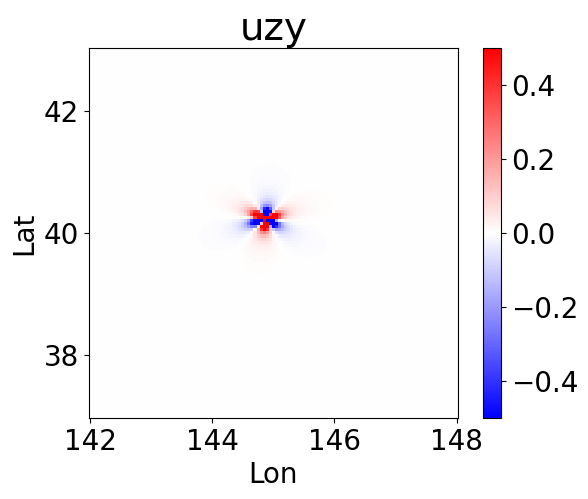

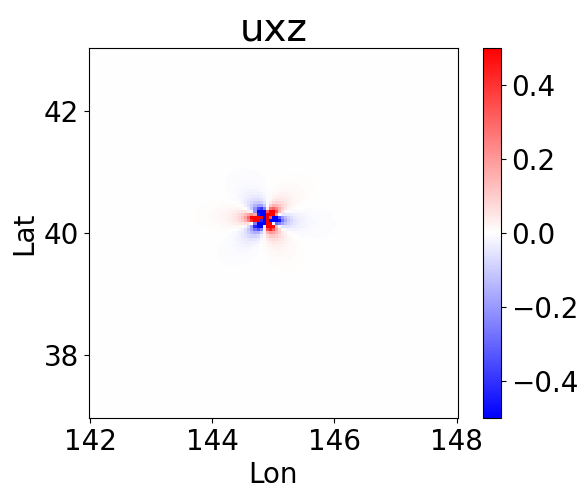

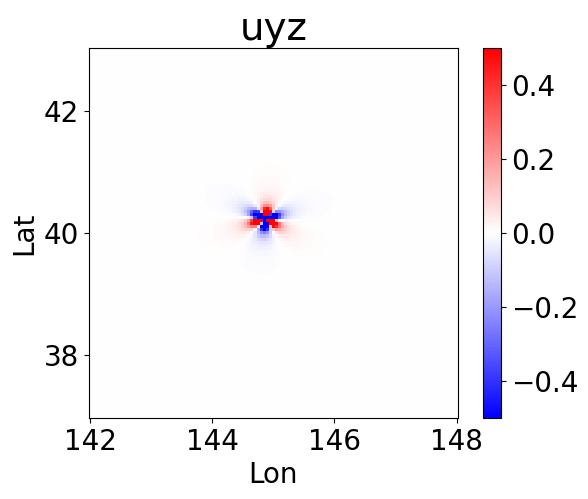

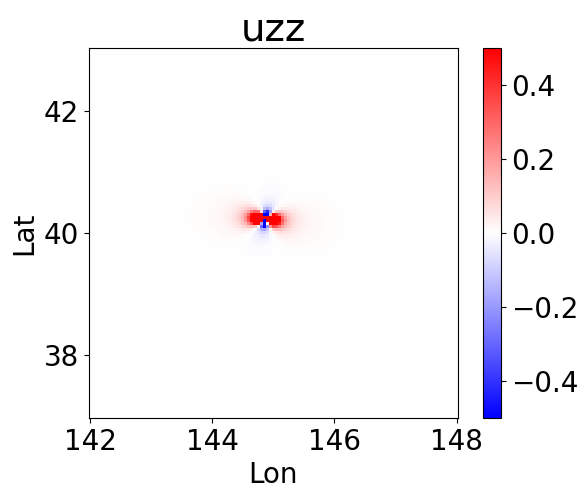

In [6]:
for i, var in enumerate(var_list):

    fig, ax = plt.subplots()
    im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.5, vmax=0.5)
    ax.set_aspect("equal")
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(var, fontsize=28)
    fig.colorbar(im)
    fig.show()

# Rectangular fault

In [7]:
# domain
lon_min, lon_max = 142, 148
lat_min, lat_max = 37, 43
dlon, dlat = 0.05, 0.05
nlon, nlat = int((lon_max-lon_min)/dlon)+1, int((lat_max-lat_min)/dlon)+1
lon_mid, lat_mid = (lon_min+lon_max)/2, (lat_min+lat_max)/2


# coordinate transformation
ll2xy = pyproj.Transformer.from_crs(
    crs_from="EPSG:4326", # WGS84
    crs_to=f"+proj=tmerc +lon_0={lon_mid} +lat_0={lat_mid} +ellps=WGS84 +datum=WGS84 +units=km", 
    always_xy=True
)

lon = jnp.linspace(lon_min, lon_max, nlon)
lat = jnp.linspace(lat_min, lat_max, nlat)
Lon, Lat = jnp.meshgrid(lon, lat)
X, Y = ll2xy.transform(Lon, Lat)

# source parameters
lat_fault = 40.2224
lon_fault = 144.8678
x_fault, y_fault = ll2xy.transform(lon_fault, lat_fault) # km

x_fault = jnp.array(x_fault)
y_fault = jnp.array(y_fault)
depth, length, width = 0.1, 218.0, 46.0 # km
strike = jnp.array(189.0)
dip = jnp.array(60.0)
rake = jnp.array(270.0)
slip = jnp.array(5.62)

## `z` is not given (`SRECTF` is called)

In [8]:
coords = {
    "x": X,
    "y": Y
}
params = {
    "x_fault": x_fault,
    "y_fault": y_fault,
    "depth": depth,
    "length": length,
    "width": width,
    "strike": strike,
    "dip": dip,
    "rake": rake,
    "slip": slip
}

out = okada.compute(coords, params, compute_strain=True, is_degree=True, fault_origin="topleft")
out

[Array([[-0.02941661, -0.02922785, -0.02901495, ...,  0.04795753,
          0.04749313,  0.04702435],
        [-0.03102013, -0.03085186, -0.03065686, ...,  0.04950303,
          0.04899564,  0.04848772],
        [-0.03271396, -0.03257   , -0.03239721, ...,  0.05108751,
          0.05053565,  0.04998409],
        ...,
        [-0.01483598, -0.01469467, -0.01454761, ...,  0.01005388,
          0.01016319,  0.01026789],
        [-0.01431794, -0.01417987, -0.0140343 , ...,  0.00964547,
          0.00975088,  0.00985849],
        [-0.01382335, -0.0136843 , -0.01354377, ...,  0.00925354,
          0.00936193,  0.00946472]], dtype=float32),
 Array([[-0.00680829, -0.00670016, -0.0065737 , ..., -0.02389151,
         -0.0234356 , -0.02298599],
        [-0.00717542, -0.00707924, -0.00696371, ..., -0.02427329,
         -0.0237962 , -0.02332699],
        [-0.00755177, -0.0074674 , -0.00736558, ..., -0.02464373,
         -0.0241456 , -0.02365476],
        ...,
        [ 0.00939332,  0.00929824,  0.0

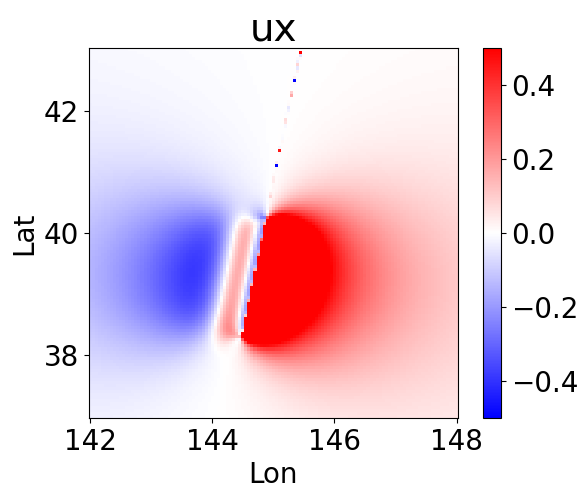

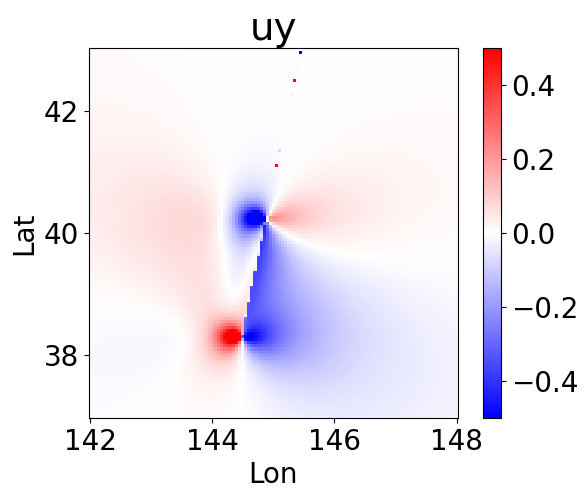

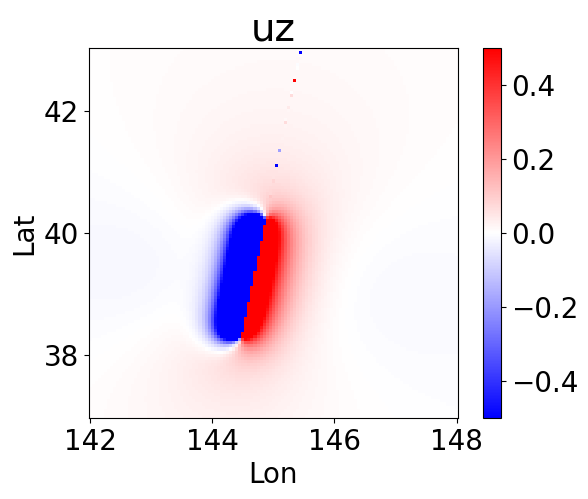

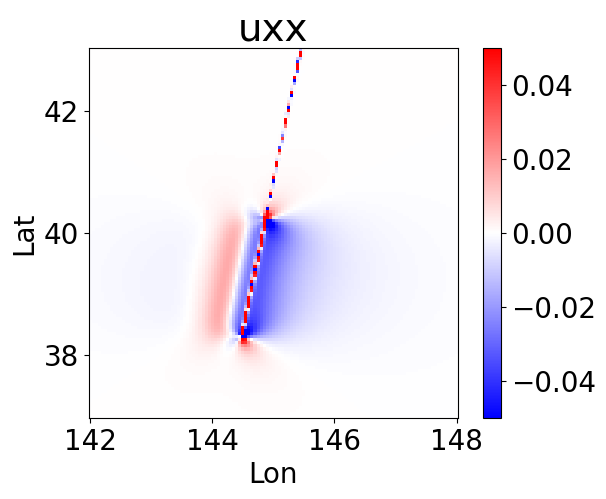

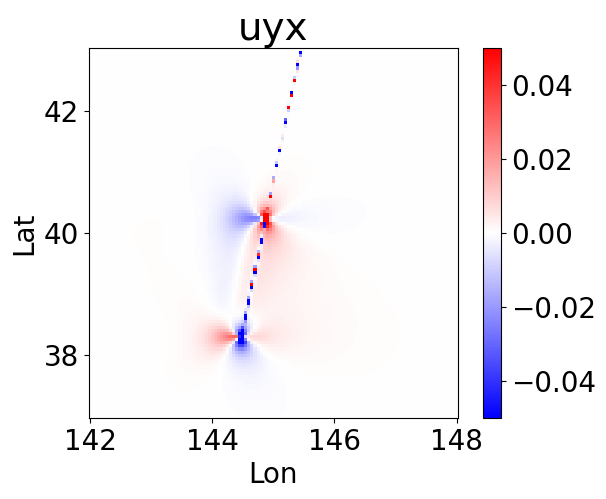

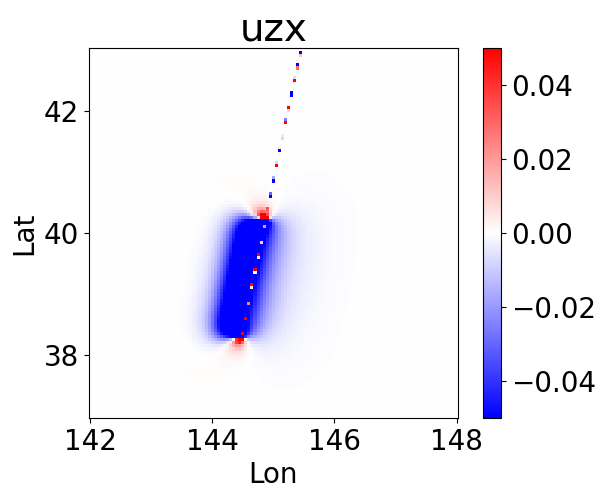

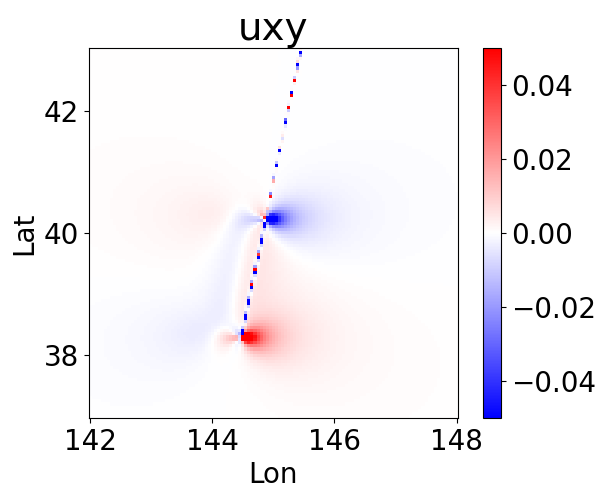

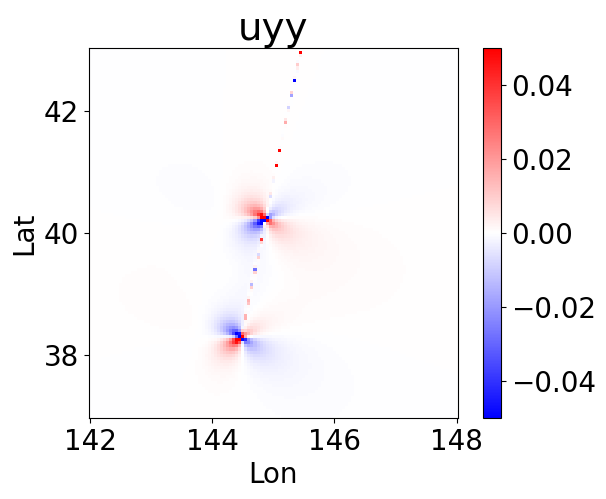

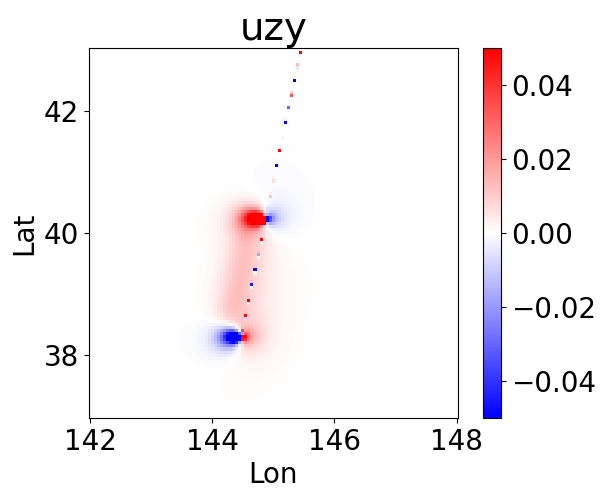

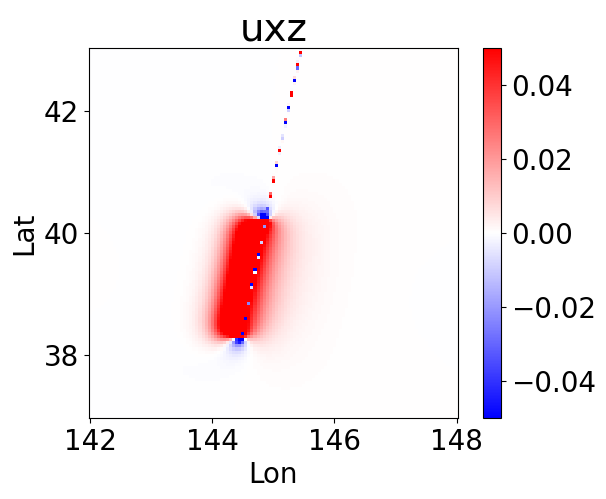

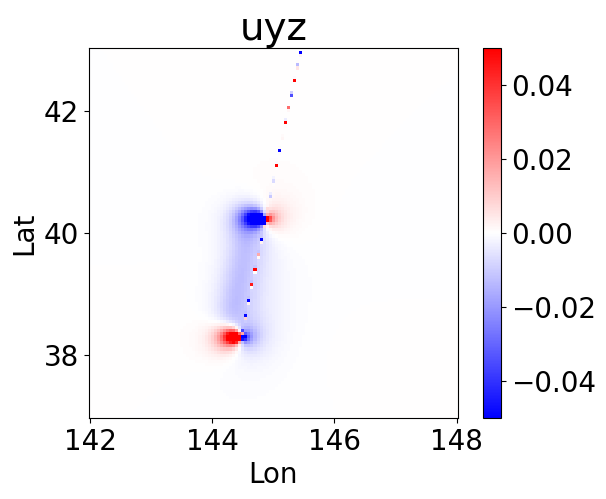

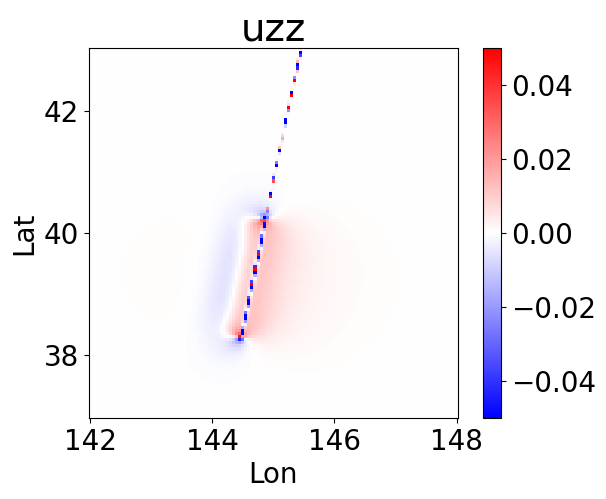

In [9]:
for i, var in enumerate(var_list):

    fig, ax = plt.subplots()
    if i<3:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.5, vmax=0.5)
    else:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.05, vmax=0.05)

    ax.set_aspect("equal")
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(var, fontsize=28)
    fig.colorbar(im)
    fig.show()

## `z` is given (`DC3D` is called)

In [10]:
Z = jnp.zeros_like(X)


coords = {
    "x": X,
    "y": Y,
    "z": Z
}
params = {
    "x_fault": x_fault,
    "y_fault": y_fault,
    "depth": depth,
    "length": length,
    "width": width,
    "strike": strike,
    "dip": dip,
    "rake": rake,
    "slip": slip
}

out = okada.compute(coords, params, compute_strain=True, is_degree=True, fault_origin="topleft")
out

[Array([[-0.02941652, -0.02922828, -0.02901454, ...,  0.04795758,
          0.0474926 ,  0.04702399],
        [-0.03102017, -0.03085216, -0.03065713, ...,  0.04950325,
          0.04899625,  0.04848692],
        [-0.03271373, -0.03256975, -0.03239798, ...,  0.05108783,
          0.05053627,  0.04998405],
        ...,
        [-0.01483649, -0.01469517, -0.01454761, ...,  0.0100541 ,
          0.01016355,  0.01026792],
        [-0.01431772, -0.01418023, -0.01403447, ...,  0.00964537,
          0.00975142,  0.00985817],
        [-0.0138236 , -0.01368417, -0.0135438 , ...,  0.00925352,
          0.00936112,  0.00946466]], dtype=float32),
 Array([[-0.00680775, -0.00669986, -0.00657417, ..., -0.02389116,
         -0.02343587, -0.02298521],
        [-0.00717561, -0.00707962, -0.00696386, ..., -0.02427344,
         -0.0237969 , -0.02332747],
        [-0.00755188, -0.00746738, -0.00736585, ..., -0.02464318,
         -0.02414473, -0.02365499],
        ...,
        [ 0.00939274,  0.00929818,  0.0

In [11]:
# import os
# os.makedirs("figs", exist_ok=True)

In [12]:
ss = jnp.sin(jnp.deg2rad(strike))
cs = jnp.cos(jnp.deg2rad(strike))
sd = jnp.sin(jnp.deg2rad(dip))
cd = jnp.cos(jnp.deg2rad(dip))

x_corners = [
    x_fault,
    x_fault               + width * cd * cs,
    x_fault + length * ss + width * cd * cs,
    x_fault + length * ss
]
y_corners = [
    y_fault,
    y_fault               - width * cd * ss,
    y_fault + length * cs - width * cd * ss,
    y_fault + length * cs
]

lon_corners, lat_corners = ll2xy.transform(x_corners, y_corners, direction = "INVERSE")
corners = jnp.column_stack((jnp.array(lon_corners), jnp.array(lat_corners)))

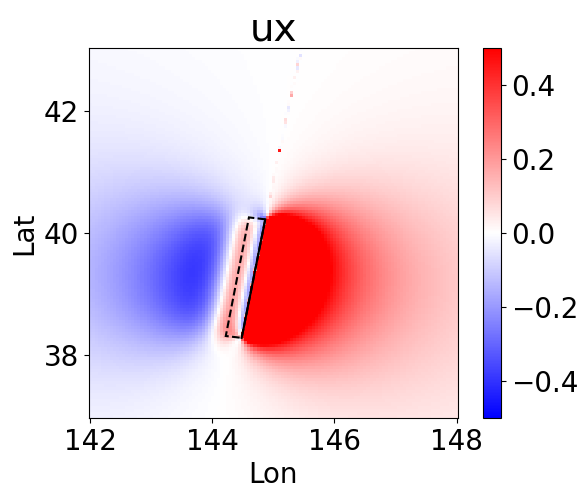

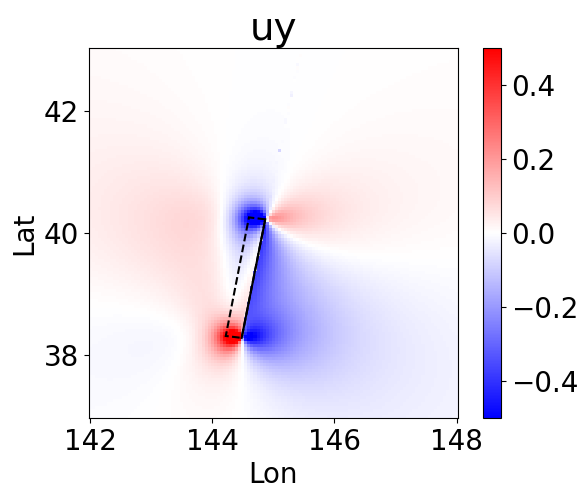

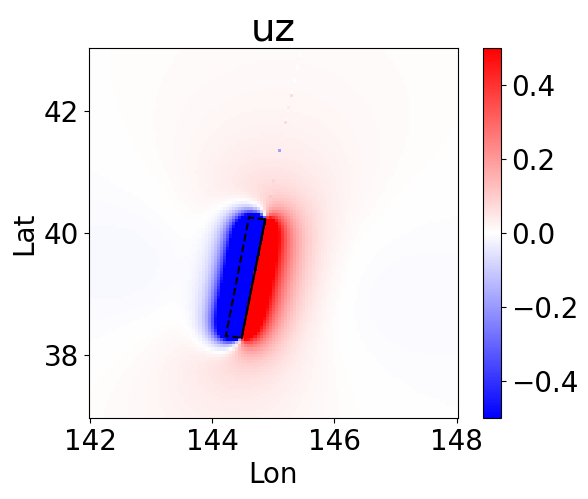

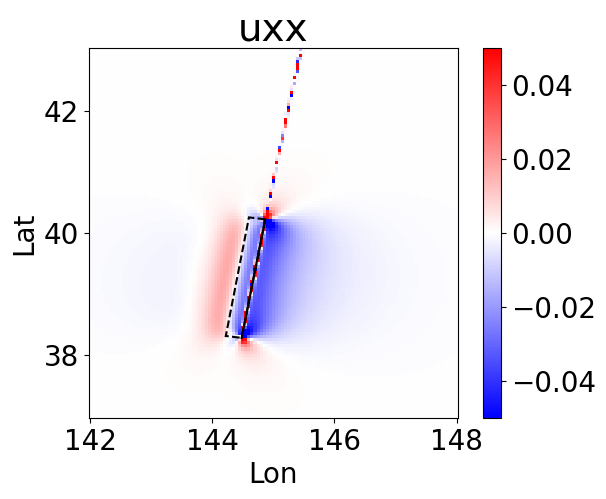

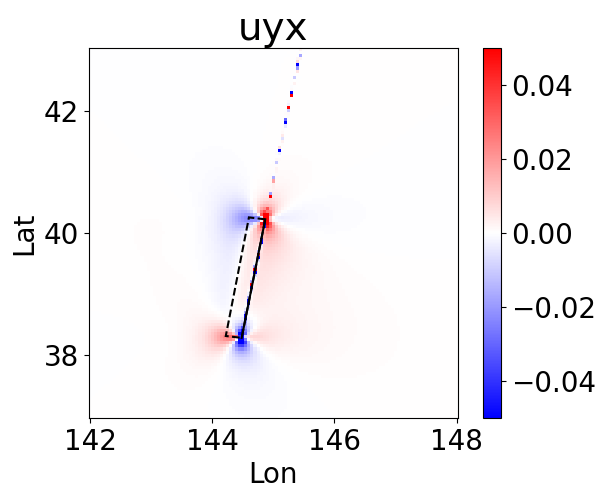

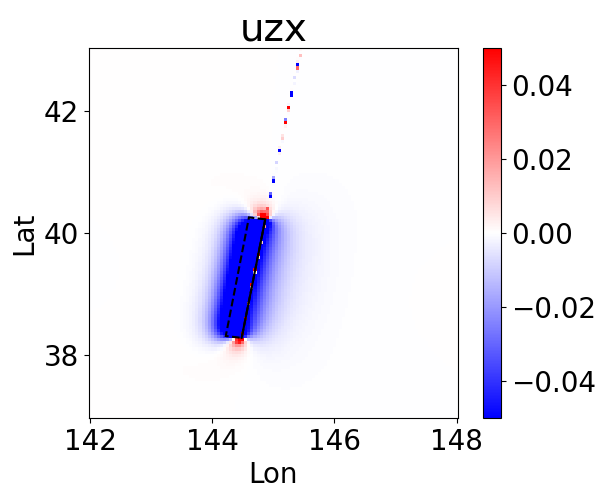

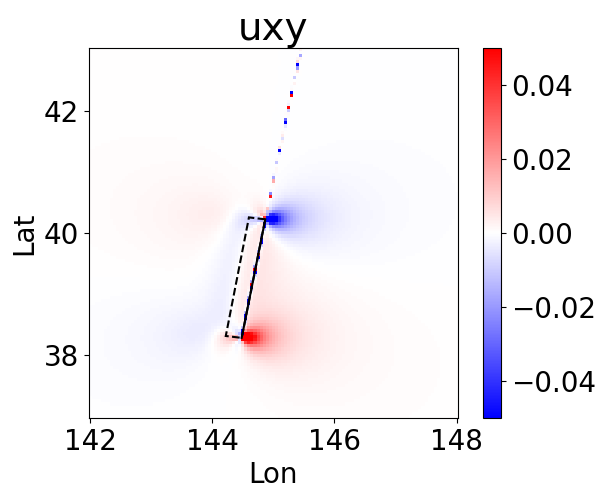

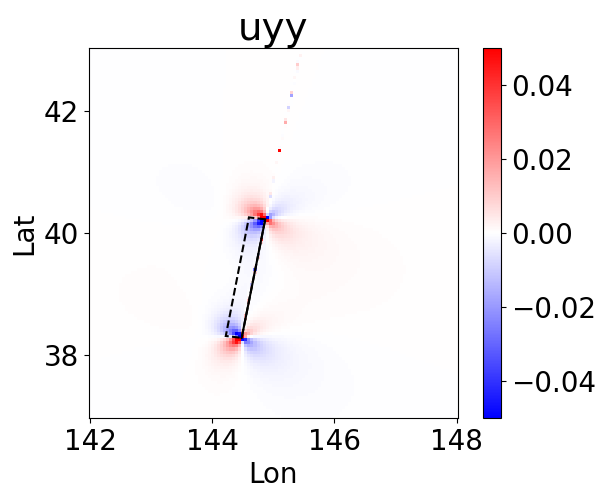

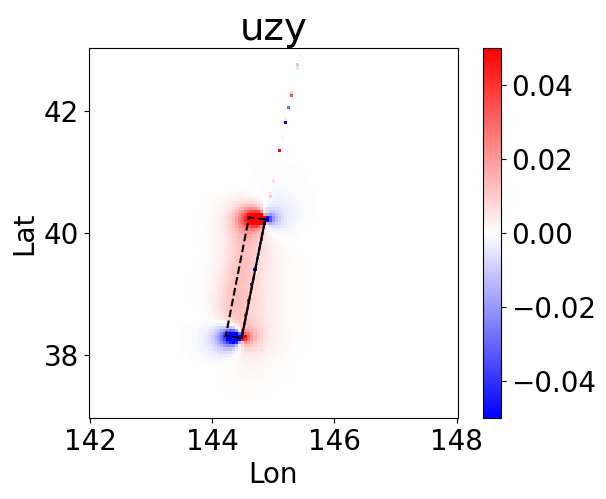

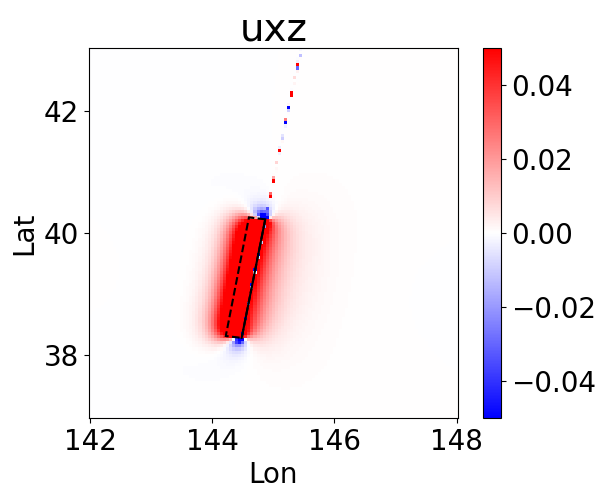

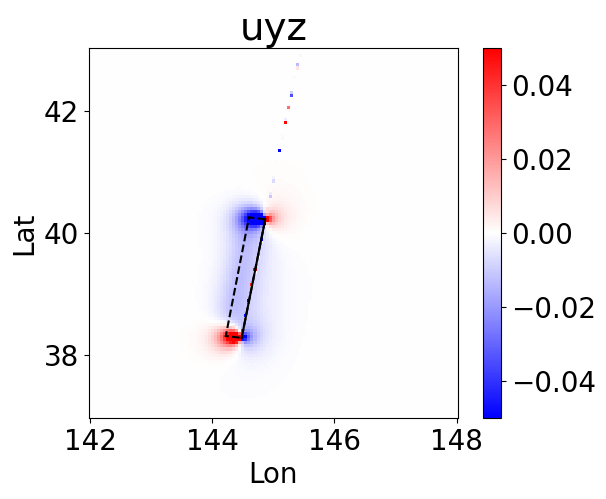

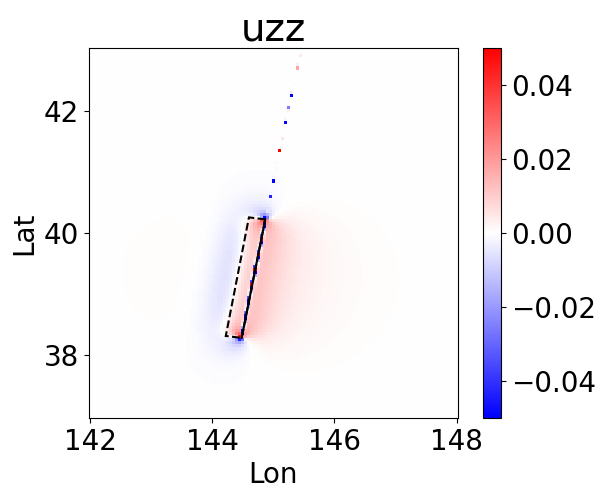

In [14]:
for i, var in enumerate(var_list):

    fig, ax = plt.subplots()
    
    if i<3:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.5, vmax=0.5)
    else:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.05, vmax=0.05)

    rect = patches.Polygon(corners, ls="--", lw=1.5, closed=True, edgecolor='black', fill=False)
    ax.add_patch(rect)
    ax.plot(    
        [corners[0, 0], corners[3, 0]],
        [corners[0, 1], corners[3, 1]],
        color='black', lw=1.5
    )

    ax.set_aspect("equal")
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(var, fontsize=28)
    fig.colorbar(im)
    fig.show()
    
    # plt.tight_layout()
    # fig.savefig(f"figs/{var}.png")

### For the case of `fault_origin="center"`

In [15]:
out = okada.compute(coords, params, compute_strain=True, is_degree=True, fault_origin="center")
out

[Array([[-0.0144769 , -0.01431346, -0.01414204, ...,  0.0251271 ,
          0.02514863,  0.0251621 ],
        [-0.01512921, -0.01496593, -0.01479393, ...,  0.02599203,
          0.02600326,  0.02600743],
        [-0.01581437, -0.01565132, -0.01548064, ...,  0.02689003,
          0.02689143,  0.02688456],
        ...,
        [-0.03528995, -0.03535628, -0.03540996, ...,  0.02206376,
          0.02213526,  0.02219611],
        [-0.03394774, -0.03399342, -0.03402666, ...,  0.02103296,
          0.02111743,  0.02118793],
        [-0.03266107, -0.03268889, -0.03270278, ...,  0.02005342,
          0.02014764,  0.02022829]], dtype=float32),
 Array([[-0.00404485, -0.00398067, -0.00391036, ..., -0.01477116,
         -0.01469159, -0.0146096 ],
        [-0.00423884, -0.00417572, -0.00410785, ..., -0.01516723,
         -0.01507957, -0.01498766],
        [-0.00444217, -0.00438046, -0.00431329, ..., -0.01557396,
         -0.01547521, -0.01537226],
        ...,
        [ 0.02024688,  0.02041012,  0.0

In [16]:
x_corners = [
    x_fault - 0.5 * length * ss - 0.5 * width * cd * cs,
    x_fault - 0.5 * length * ss + 0.5 * width * cd * cs,
    x_fault + 0.5 * length * ss + 0.5 * width * cd * cs,
    x_fault + 0.5 * length * ss - 0.5 * width * cd * cs,
]
y_corners = [
    y_fault - 0.5 * length * cs + 0.5 * width * cd * ss,
    y_fault - 0.5 * length * cs - 0.5 * width * cd * ss,
    y_fault + 0.5 * length * cs - 0.5 * width * cd * ss,
    y_fault + 0.5 * length * cs + 0.5 * width * cd * ss,
]

lon_corners, lat_corners = ll2xy.transform(x_corners, y_corners, direction = "INVERSE")
corners = jnp.column_stack((jnp.array(lon_corners), jnp.array(lat_corners)))

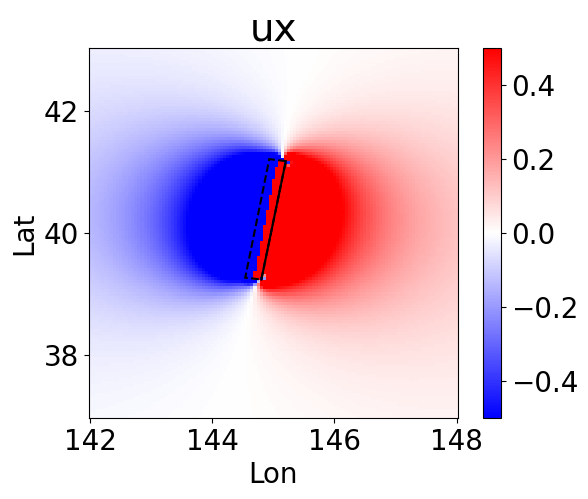

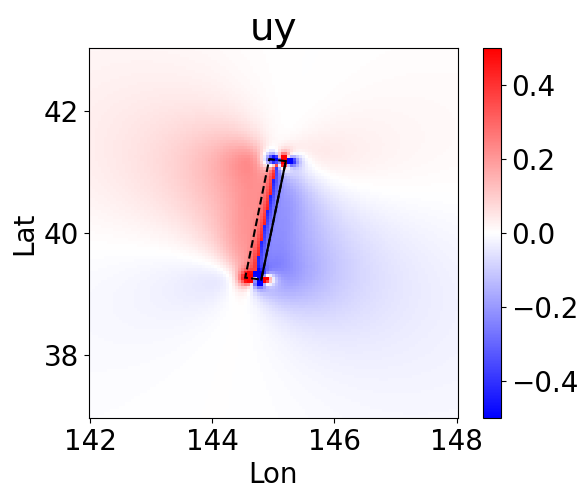

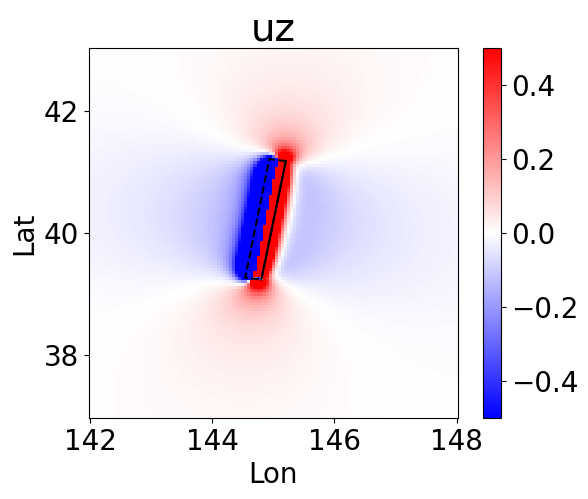

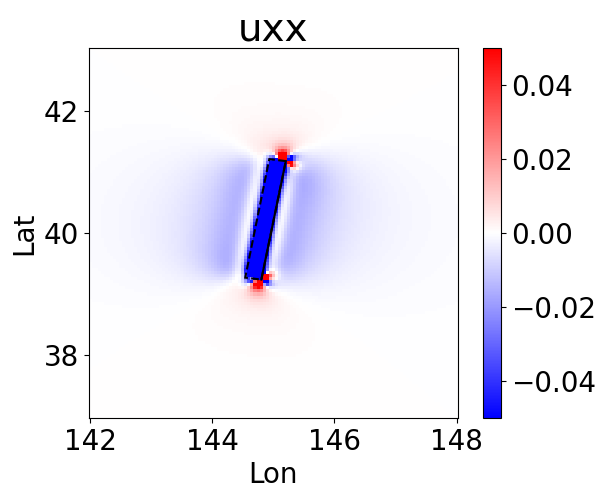

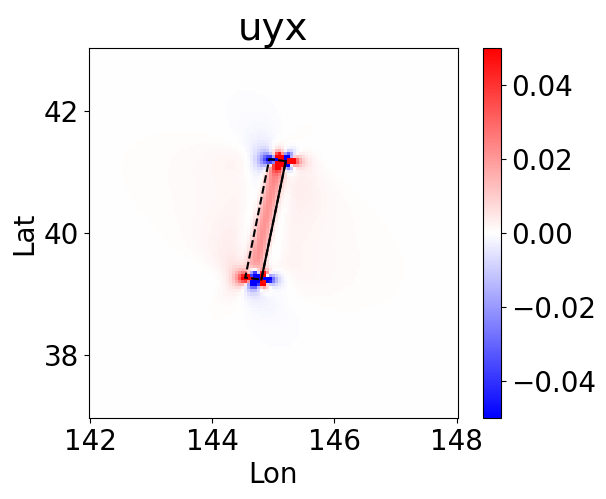

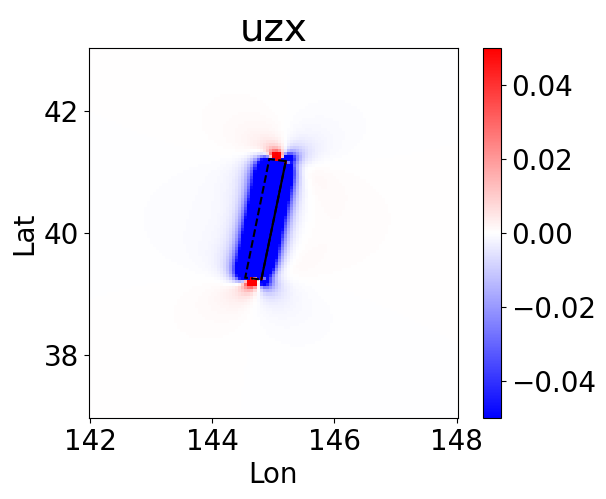

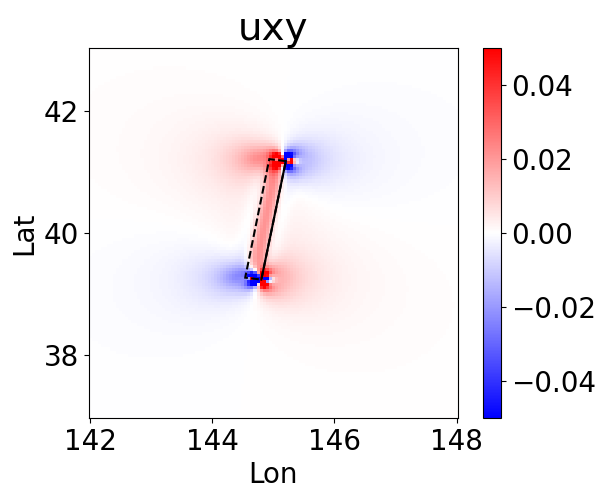

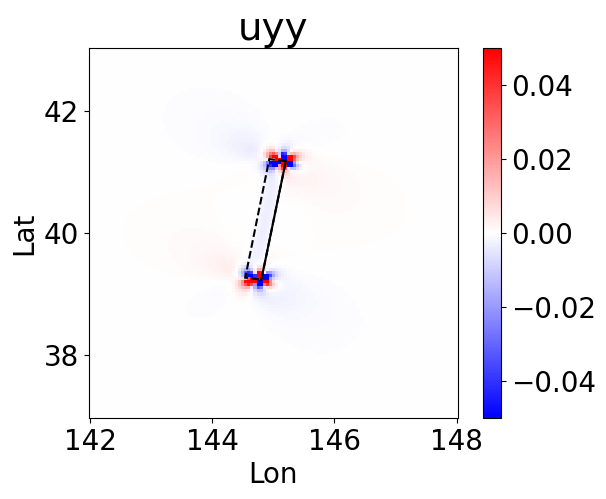

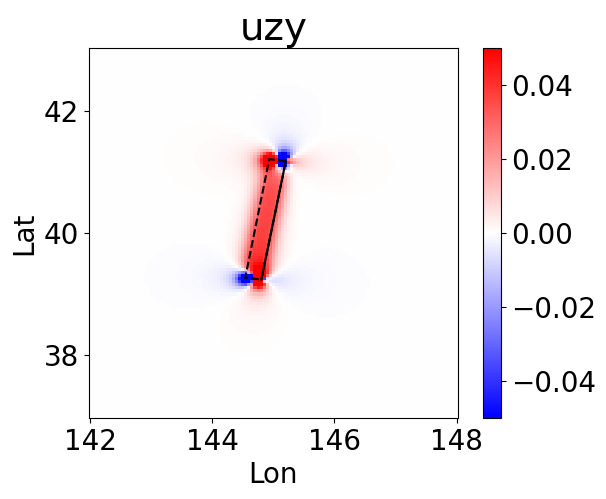

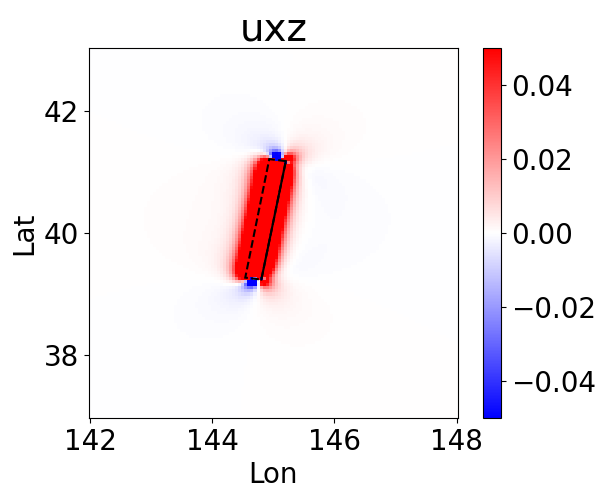

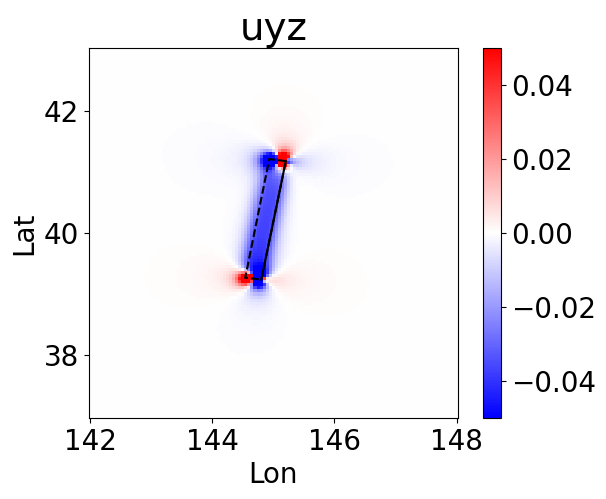

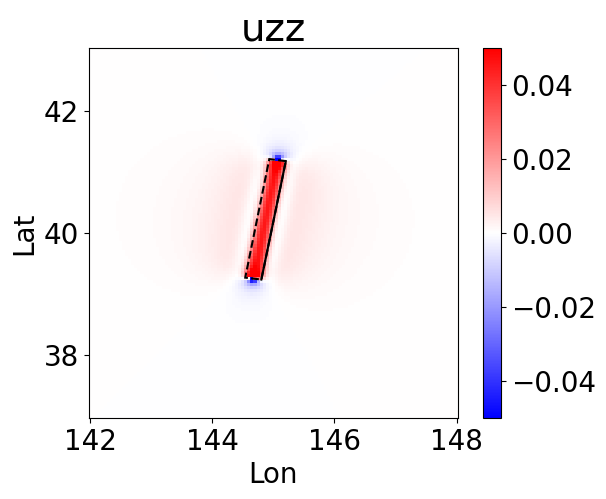

In [17]:
for i, var in enumerate(var_list):

    fig, ax = plt.subplots()
    
    if i<3:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.5, vmax=0.5)
    else:
        im = ax.pcolormesh(Lon, Lat, out[i], cmap="bwr", vmin=-0.05, vmax=0.05)

    rect = patches.Polygon(corners, ls="--", lw=1.5, closed=True, edgecolor='black', fill=False)
    ax.add_patch(rect)
    ax.plot(    
        [corners[0, 0], corners[3, 0]],
        [corners[0, 1], corners[3, 1]],
        color='black', lw=1.5
    )

    ax.set_aspect("equal")
    ax.set_xlabel("Lon")
    ax.set_ylabel("Lat")
    ax.set_title(var, fontsize=28)
    fig.colorbar(im)
    fig.show()